Import bibliotek 

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score)

import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

Wczytanie danych bez nagłowków. 

In [2]:
df = pd.read_excel('default_of_credit_card_clients.xls', engine='xlrd', header=1)

## Wstępne przejrzenie danych

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

Usunięcie zbędnej kolumny ID

In [4]:
df = df.drop(columns=['ID'])

Sprawdzenie danych w kolumnie z celem projektu czyli kolumnie default payment next month, jednocześnie zmieniam jej nazwę dla uproszczenia. 

In [5]:
df = df.rename(columns={'default payment next month': 'default'})

print("Shape:", df.shape)

print(f'\nliczba wystąpień wartości w kolumnie: {df['default'].value_counts()}')

print(f'\n% wystąpień wartości w kolumnie: {df['default'].value_counts(normalize=True).round(3)}')

print(f'\nBraki danych: {df.isnull().sum().sum()}')

print(f"\nLiczba zduplikowanych wierszy: {df.duplicated().sum()}")

Shape: (30000, 24)

liczba wystąpień wartości w kolumnie: default
0    23364
1     6636
Name: count, dtype: int64

% wystąpień wartości w kolumnie: default
0    0.779
1    0.221
Name: proportion, dtype: float64

Braki danych: 0

Liczba zduplikowanych wierszy: 35


Wykryto 35 identycznych wierszy, należy się ich pozbyć.

In [6]:
df = df.drop_duplicates()
print(f"Rozmiar danych po usunięciu duplikatów: {df.shape}")

Rozmiar danych po usunięciu duplikatów: (29965, 24)


Sprawdzenie danych w kolumnach zawierających dane kategoryczne. 

In [7]:
calegorical_value_check = ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'] 
for col in calegorical_value_check:
    wartosci = df[col].value_counts().sort_index()
    print(f"\nKolumna {col}")
    print(wartosci)


Kolumna SEX
SEX
1    11874
2    18091
Name: count, dtype: int64

Kolumna EDUCATION
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64

Kolumna MARRIAGE
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64

Kolumna AGE
AGE
21      67
22     560
23     930
24    1126
25    1185
26    1252
27    1475
28    1406
29    1602
30    1394
31    1213
32    1157
33    1146
34    1161
35    1113
36    1107
37    1041
38     943
39     951
40     870
41     822
42     792
43     669
44     700
45     617
46     570
47     501
48     466
49     449
50     411
51     340
52     304
53     325
54     247
55     209
56     178
57     122
58     122
59      83
60      67
61      56
62      44
63      31
64      31
65      24
66      25
67      16
68       5
69      15
70      10
71       3
72       3
73       4
74       1
75       3
79       1
Name: count, dtype: int64

Kolumna PAY_0
PAY_0
-2     2750
-1     5682
 0

Kolumna MARRIAGE oraz EDUCATION mają wartości inne niż oczekiwane, wartości takie zostaną przypisane do kategorii 'others' w obu przypadkach. 

In [8]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

Sprawdzenie kolumn z danymi ciągłymi. 

In [9]:
continuous_value_check = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df[continuous_value_check].describe().round(2)

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00
mean,167442.01,51283.01,49236.37,47067.92,43313.33,40358.33,38917.01,5670.10,5927.98,5231.69,4831.62,4804.90,5221.50
std,129760.14,73658.13,71195.57,69371.35,64353.51,60817.13,59574.15,16571.85,23053.46,17616.36,15674.46,15286.37,17786.98
min,10000.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,3595.00,3010.00,2711.00,2360.00,1787.00,1262.00,1000.00,850.00,390.00,300.00,261.00,131.00
50%,140000.00,22438.00,21295.00,20135.00,19081.00,18130.00,17124.00,2102.00,2010.00,1804.00,1500.00,1500.00,1500.00
75%,240000.00,67260.00,64109.00,60201.00,54601.00,50247.00,49252.00,5008.00,5000.00,4512.00,4016.00,4042.00,4000.00
max,1000000.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00


Te dane wydają się być prawidłowe. Nie ma wartości nierealistycznych, lub oczywiście błędnych jak np ujemna wpłata. Wstępne sprawdzanie danych należy uznać za zakończone. 

In [10]:
kat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in kat_cols:
    df[col] = df[col].astype('category')

## EDA

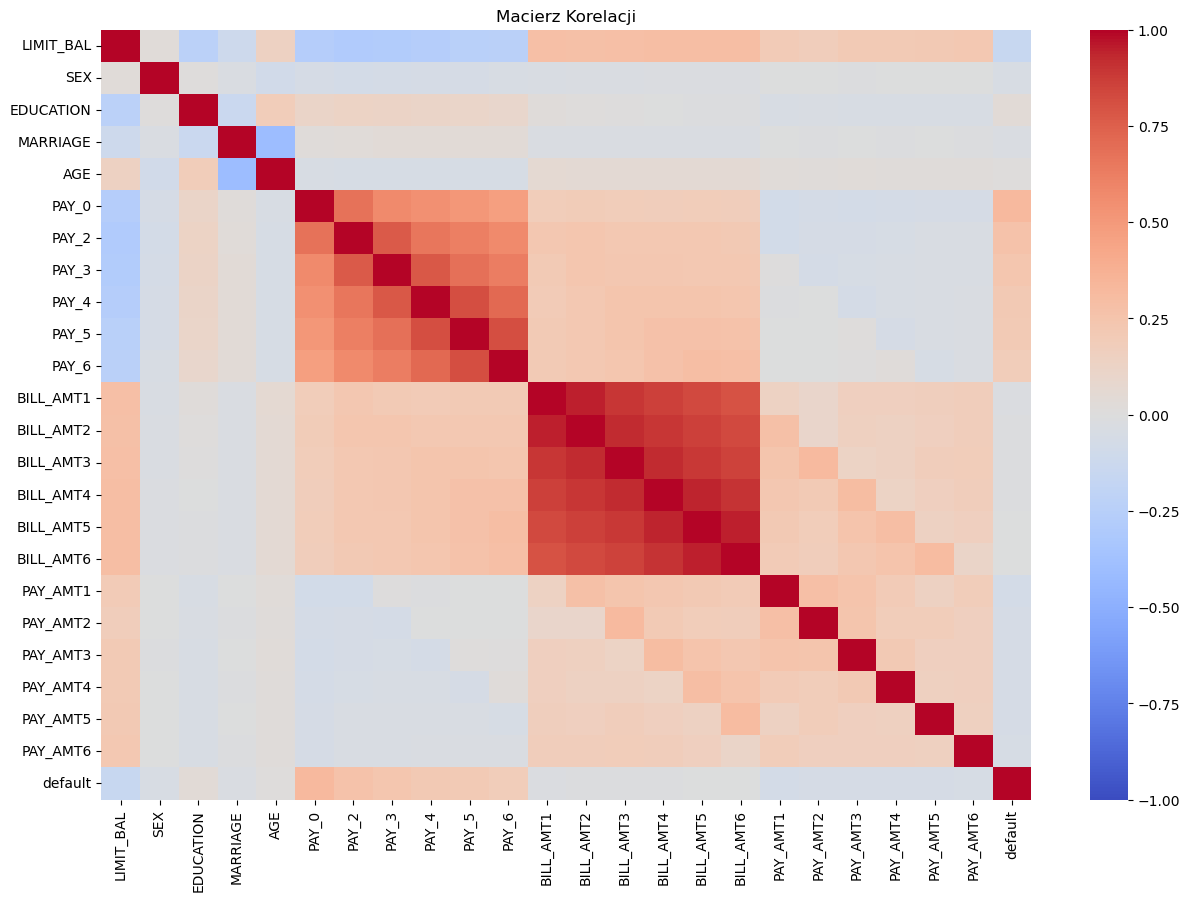

In [11]:
plt.figure(figsize=(15, 10))
# Liczymy korelację (możemy użyć np. metody Spearmana lub domyślnej Pearsona)
korelacje = df.corr()
sns.heatmap(korelacje, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Macierz Korelacji")
plt.show()

Wraz ze wzrostem limitu spada default, jednocześnie limit rośnie, wraz z wiekiem klienta, oraz edukacją, chociaż na heatmapie jest tam niebieski bo najwyższa edukacja ma nr 1. Limit ma również lekki przechył w kierunku kobiet (dostają większy limit od mężczyzn ale nieznacznie) , małżeństwo nie ma praktycznie znaczenia dla limitu. Najważniejsza jest jednak dość silna korelacja dodatnia między default a PAY_0 - PAY_6. Nawet zaległości w spłatach sprzed 6 miesięcy mocno wpływają na default a im bliżej "dnia dzisiejszego" tym korelacja rośnie.  

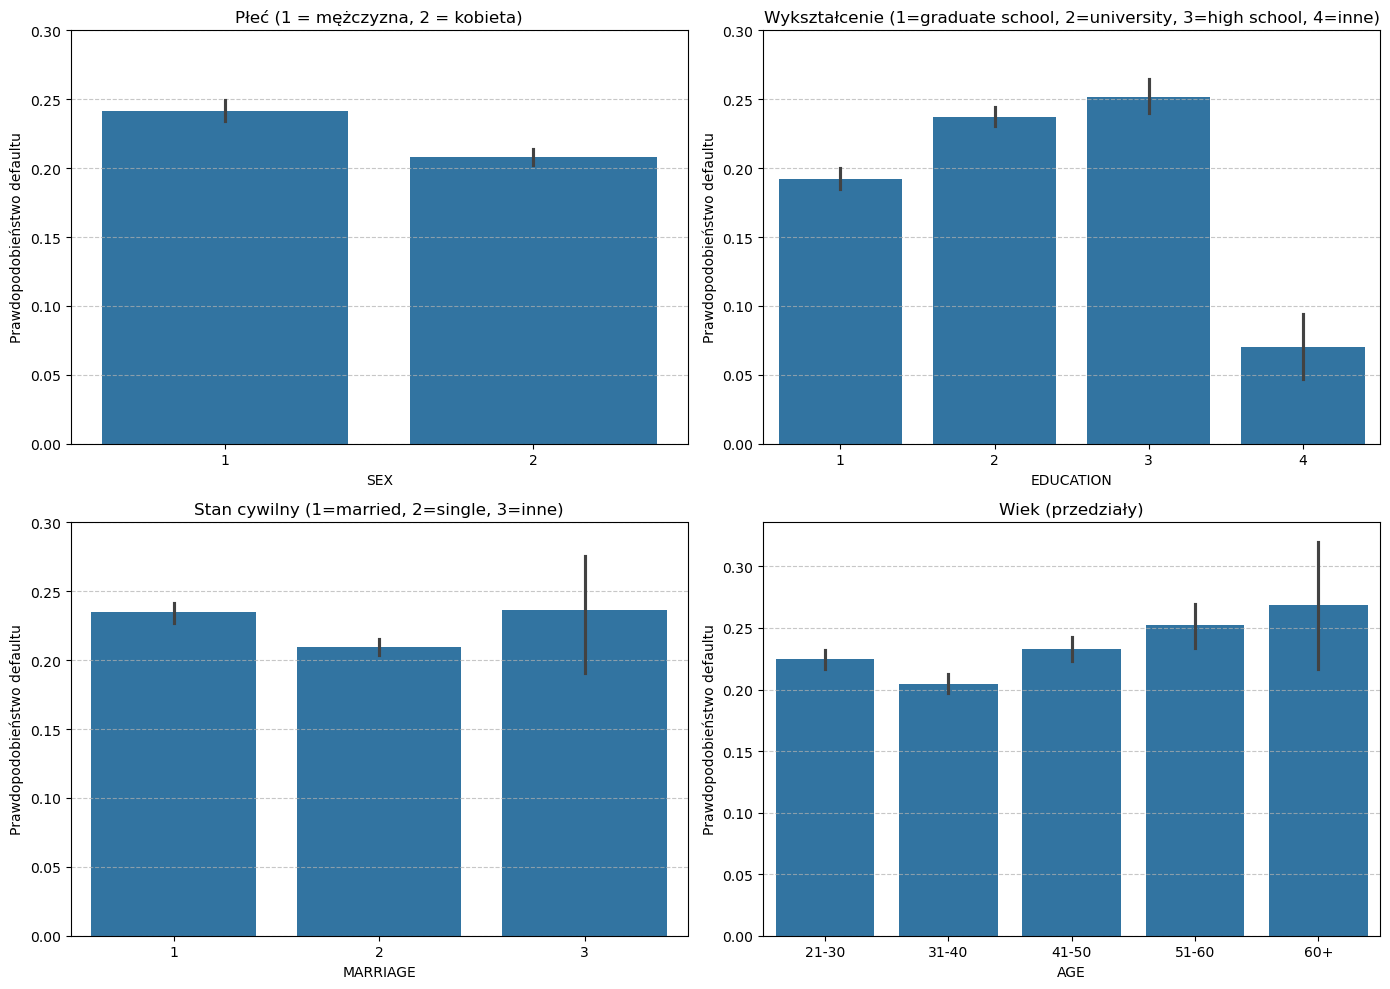

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x='SEX', y='default', data=df, ax=axes[0, 0])
axes[0, 0].set_title("Płeć (1 = mężczyzna, 2 = kobieta)")
axes[0, 0].set_ylabel("Prawdopodobieństwo defaultu")
axes[0, 0].set_xlabel("SEX")
axes[0, 0].set_yticks(np.arange(0, 0.31, 0.05))
axes[0, 0].yaxis.grid(True, linestyle='--', alpha=0.7)

sns.barplot(x='EDUCATION', y='default', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Wykształcenie (1=graduate school, 2=university, 3=high school, 4=inne)")
axes[0, 1].set_ylabel("Prawdopodobieństwo defaultu")
axes[0, 1].set_xlabel("EDUCATION")
axes[0, 1].set_yticks(np.arange(0, 0.31, 0.05))
axes[0, 1].yaxis.grid(True, linestyle='--', alpha=0.7)

sns.barplot(x='MARRIAGE', y='default', data=df, ax=axes[1, 0])
axes[1, 0].set_title("Stan cywilny (1=married, 2=single, 3=inne)")
axes[1, 0].set_ylabel("Prawdopodobieństwo defaultu")
axes[1, 0].set_xlabel("MARRIAGE")
axes[1, 0].set_yticks(np.arange(0, 0.31, 0.05))
axes[1, 0].yaxis.grid(True, linestyle='--', alpha=0.7)

df['AGE_BIN'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=['21-30', '31-40', '41-50', '51-60', '60+'])
sns.barplot(x='AGE_BIN', y='default', data=df, ax=axes[1, 1])
axes[1, 1].set_title("Wiek (przedziały)")
axes[1, 1].set_ylabel("Prawdopodobieństwo defaultu")
axes[1, 1].set_xlabel("AGE")
axes[1, 1].set_yticks(np.arange(0, 0.31, 0.05))
axes[1, 1].yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
df = df.drop(columns=['AGE_BIN'])

Tutaj mamy zobrazowane to co widać było na heatmapie. Kobiety nieznacznie rzadziej bankrutują, tak samo wyższe wykształcenie wpływa na wyższe zarobki a co za tym idzie mniejszą szansę na bankructwo, status cywilny ma minimalne znaczenie, chociaż ciekaw jest że singiel jest lepiej traktowany, może mieć to związek z faktem iż w małżeństwach mogą występować dzieci a co za tym idzie wyższe koszty utrzymania. Zależność wieku też można łatwo wytłumaczyć, wiek 31-40 jest najstabilniejszy jeśli chodzi o karierę i możliwości zarobkowe a w raz z wiekiem ryzyko utraty pracy / choroby rośnie.

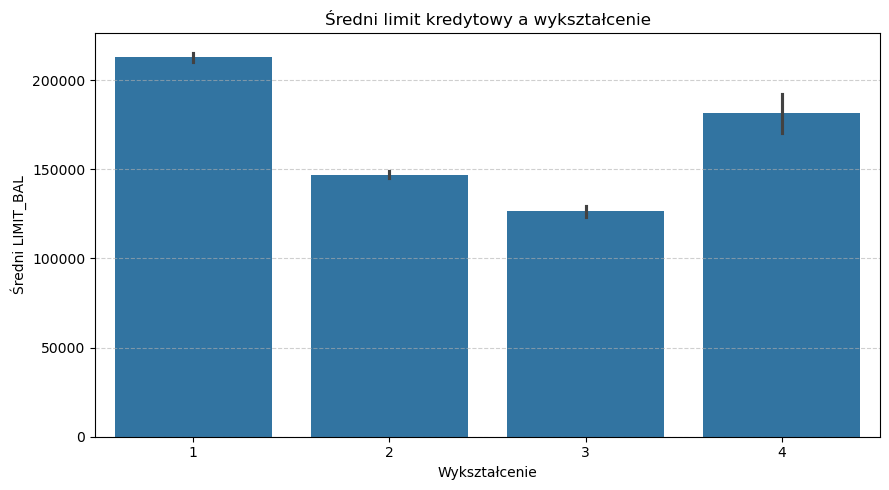

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(x='EDUCATION', y='LIMIT_BAL', data=df, errorbar=('ci', 95))

plt.title("Średni limit kredytowy a wykształcenie")
plt.xlabel("Wykształcenie")
plt.ylabel("Średni LIMIT_BAL")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Wyżej na wykresie z prawdopodobieństwie defoult / edukacja można było zauważyć że grupa inne ma bardzo niską szansę na bankructwo, jednocześnie na tym wykresie widzimy że ma ona średnio dość wysokie limity. Oznaczać to może np kredyty dla firm, gdzie nie podaje się wykształcenia, ewentualnie jakąś specjalną grupę ludzi np celebrytów, właścicieli firm czy polityków którzy dostają kredyt mimo że celowo nieuzupełniają rubryki "edukacja". Kategoria ta staoni jednak raptem 1,56% danych i można to traktować jako ciekawostkę niż coś co może mieć wpływ na wyniki. Z tego samego powodu nie ma sensu usuwać tych danych.

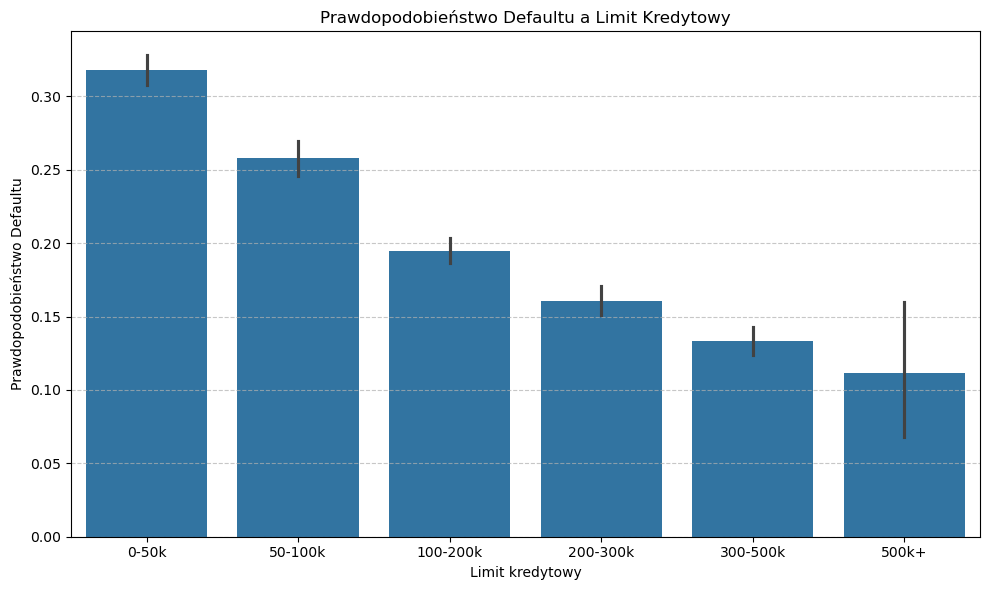

In [14]:
df['LIMIT_BIN'] = pd.cut(df['LIMIT_BAL'], bins=[0, 50000, 100000, 200000, 300000, 500000, 10000000], labels=['0-50k', '50-100k', '100-200k', '200-300k', '300-500k', '500k+'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='LIMIT_BIN', y='default', data=df, errorbar=('ci', 95))

plt.title("Prawdopodobieństwo Defaultu a Limit Kredytowy")
plt.ylabel("Prawdopodobieństwo Defaultu")
plt.xlabel("Limit kredytowy")
ax.set_yticks(np.arange(0, 0.35, 0.05))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)
plt.tight_layout()
plt.show()
df = df.drop(columns=['LIMIT_BIN'])

Tutaj widzimy ciekawą zależność, im niższy limit tym większe ryzyko. Założenie (w tych danych prawdopodobnie słuszne) że każdy bierze maksymalny możliwy limit powoduje że osoby które otrzymały duży limit mają jednocześnie bardzo duże dochody a przez to szansa na ich bankructwo jest zmiejsza niż osób które mają mały limit. 

Utworzenie dodatkowych kolumn zawierających łączną liczbę opóźnień ('TIMES_DELAYED'), oraz maksymalną wielkość opóźnienia (MAX_DELAY')

In [15]:
columns_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['TIMES_DELAYED'] = (df[columns_pay] > 0).sum(axis=1)
df['MAX_DELAY'] = df[columns_pay].max(axis=1).clip(lower=0)


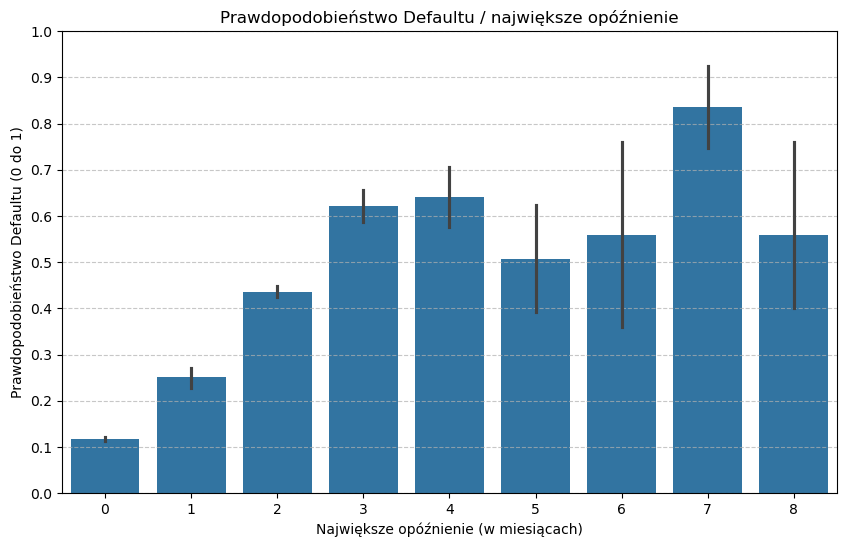

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='MAX_DELAY', y='default', data=df)

plt.title("Prawdopodobieństwo Defaultu / największe opóźnienie")
plt.ylabel("Prawdopodobieństwo Defaultu (0 do 1)")
plt.xlabel("Największe opóźnienie (w miesiącach)")

ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.show()

Widzimy że szansa na bankructwo wzrasta liniowo wraz z liczbą miesięcy maksymalnego opóźnienia, od około 12% dla osób spłacających na czas do około 63% przy największym opóźnieniu wynoszącym 3 miesiące. Później szansa bankructwa się stabilizuje, coraz dłuższe czarne kreski pionowe oznaczają małą ilość danych spełniających dane kryterium.  

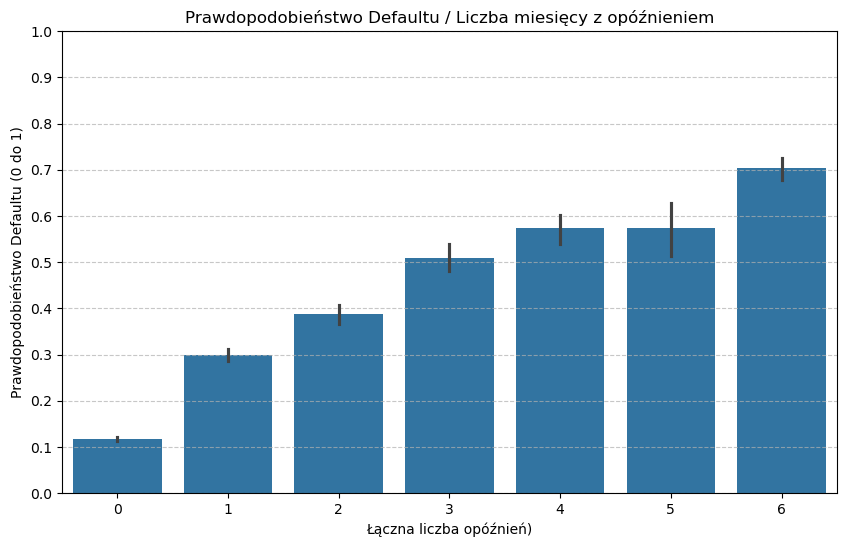

In [17]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='TIMES_DELAYED', y='default', data=df)

plt.title("Prawdopodobieństwo Defaultu / Liczba miesięcy z opóźnieniem")
plt.ylabel("Prawdopodobieństwo Defaultu (0 do 1)")
plt.xlabel("Łączna liczba opóźnień)")

ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.show()

Podobnie jak na poprzednim wykresie, tutaj też można zauważyć duży wzrost szansy na bankructwo z bazowych 12% na 30% już w przypadku jednorazowego opóźnienia. Później widzimy stabilny wzrost wraz ze wzrostem liczby opóźnień. 

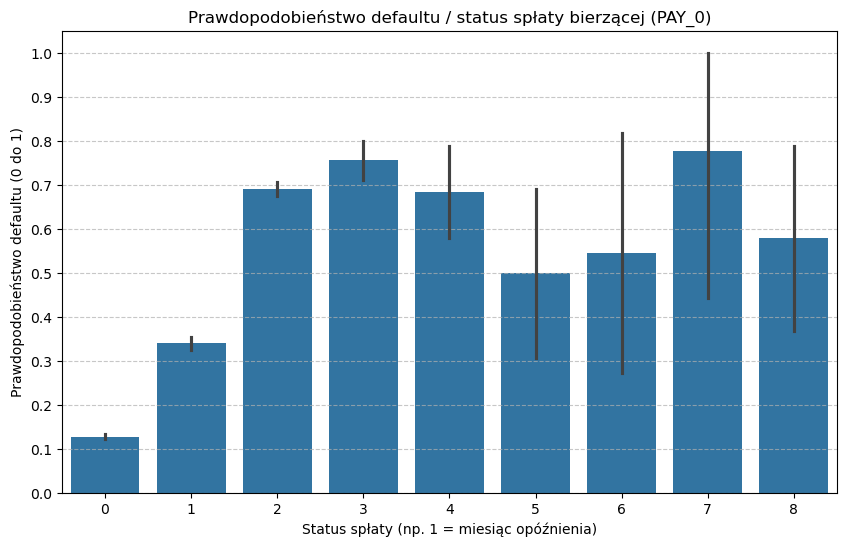

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='PAY_0', y='default', data=df[df['PAY_0'] >= 0])

plt.title("Prawdopodobieństwo defaultu / status spłaty bierzącej (PAY_0)")
plt.ylabel("Prawdopodobieństwo defaultu (0 do 1)")
plt.xlabel("Status spłaty (np. 1 = miesiąc opóźnienia)")
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.show()

Na koniec przyjrzyjmy się największej korelacji zauważonej na heatmapie kolumna PAY_0. Jak widać na wykresie bierzące opóźnienie spłaty ba bardzo duży wpływ na ocenę szansy bankructwa. 35% przy pierwszym miesiącu i aż około 69% przy dwóch oznacza że kolumna ta będzie miała bardzo duże znaczenie przy określaniu ostatecznego wyniku. 

## Uczenie modeli

Podział danych.

In [19]:
cel = 'default' 
X = df.drop(cel, axis=1)
y = df[cel]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}\n")

Rozmiar zbioru treningowego: (23972, 25)
Rozmiar zbioru testowego: (5993, 25)



sprawdzane ustawienia hiperparametrów.

In [20]:
param_grid_XGB= {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.07],
    'n_estimators': [200, 300],
    'scale_pos_weight': [3.5, 4, 4.5]
}

param_grid_LGBM = {
    'max_depth': [3, 4, 5],
    'num_leaves': [15, 31],
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05, 0.07]
}

Szukanie najlepszych hiperparamterów dla XGBoost oraz LightGBM

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_XGB, cv=cv, n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)
print("Najlepsze parametry XGBoost:", grid_xgb.best_params_)

lgbm = lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1, n_jobs=-1)
grid_lgbm = GridSearchCV(lgbm,  param_grid_LGBM,  cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_lgbm.fit(X_train, y_train)
print("Najlepsze parametry LightGBM:", grid_lgbm.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Najlepsze parametry XGBoost: {'learning_rate': 0.07, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 3.5}
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Najlepsze parametry LightGBM: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'num_leaves': 31}


definicja modeli

In [22]:
modele = {
    "Regresja Logistyczna": Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
    "Las Losowy": RandomForestClassifier(max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost (GridSearch)": grid_xgb.best_estimator_,
    "LightGBM (GridSearch)": grid_lgbm.best_estimator_
}

metryki = ['accuracy', 'recall', 'roc_auc']

nauka modeli

In [24]:
for nazwa, model in modele.items():
    wyniki = cross_validate(model, X_train, y_train, cv=cv, scoring=metryki)
    
    train_acc = wyniki['test_accuracy'].mean()
    train_rec = wyniki['test_recall'].mean()
    train_auc = wyniki['test_roc_auc'].mean()
    
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_probs_test = model.predict_proba(X_test)[:, 1]

    test_acc = accuracy_score(y_test, y_pred_test)
    test_rec = recall_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, y_probs_test)

    print(f"\n\n[{nazwa}]\n")
    print(f"    \nTRENING:")
    print(f"    Dokładność (Accuracy): {train_acc:.4f}")
    print(f"    Czułość (Recall):      {train_rec:.4f}")
    print(f"    ROC-AUC:               {train_auc:.4f}")
    print(f"    \nTEST:")
    print(f"    Dokładność (Accuracy): {test_acc:.4f}")
    print(f"    Czułość (Recall):      {test_rec:.4f}")
    print(f"    ROC-AUC:               {test_auc:.4f}")



[Regresja Logistyczna]

    
TRENING:
    Dokładność (Accuracy): 0.7450
    Czułość (Recall):      0.6359
    ROC-AUC:               0.7618
    
TEST:
    Dokładność (Accuracy): 0.7410
    Czułość (Recall):      0.6139
    ROC-AUC:               0.7543


[Las Losowy]

    
TRENING:
    Dokładność (Accuracy): 0.7848
    Czułość (Recall):      0.5813
    ROC-AUC:               0.7810
    
TEST:
    Dokładność (Accuracy): 0.7794
    Czułość (Recall):      0.5679
    ROC-AUC:               0.7690


[XGBoost (GridSearch)]

    
TRENING:
    Dokładność (Accuracy): 0.7632
    Czułość (Recall):      0.6290
    ROC-AUC:               0.7829
    
TEST:
    Dokładność (Accuracy): 0.7544
    Czułość (Recall):      0.6139
    ROC-AUC:               0.7715


[LightGBM (GridSearch)]

    
TRENING:
    Dokładność (Accuracy): 0.7550
    Czułość (Recall):      0.6467
    ROC-AUC:               0.7862
    
TEST:
    Dokładność (Accuracy): 0.7495
    Czułość (Recall):      0.6357
    ROC-AUC:           

Jak widać wszystkie 4 modele mają zbliżone wyniki, zarówno w zbiorze testowym jaki treningowym, dowodzi to braku pzetrenowania. ROC-AUC w okolicach 0.78% we wszystkich modelach oznacza że bez zaawansowanej inżynierii cech z tych danych nie można więcej wyciągnąć. Przy zachowaniu progu decyzji na 0.5 najlepiej sprawdził się LightGBM osiągając recall na poziomie ponad 64.5% w zbiorze train oraz 63.5% w test. Oznacza to że w 36% przypadków osoby które nie powinny odstać karty otrzymają ją, jednocześnie wysokie accuracy powoduje że relatywnie niewielu dobrych klientów zostanie odrzuconych. W dalszym kroku należało by doprecyzować co wg banku jest większą stratą udzielenie kredytu dla osób które nie powinny go dostać przy jednoczesnym stosunkowo niskim odsetku dobrych klientów których odrzucimy czy wręcz przeciwnie, rygorystyczne zwiększenie zabezpieczeń przed niespłacaniem kosztem dużej liczby potencjalnych dobrych klientów których odrzucimy. 

Sprawdzanie różnych progów  

In [25]:
progi = [0.5, 0.45, 0.4, 0.35]
print("TESTOWANIE PROGÓW NA ZBIORZE TESTOWYM")

for nazwa, model in modele.items():
    print(f"\n[{nazwa}]")
    
    model.fit(X_train, y_train)
    y_probas_test = model.predict_proba(X_test)[:, 1]
    for prog in progi:
        y_pred_test = (y_probas_test >= prog).astype(int)
        acc = accuracy_score(y_test, y_pred_test)
        rec = recall_score(y_test, y_pred_test)
        print(f"Próg {prog:.2f} | Dokładność (Accuracy): {acc:.4f} | Czułość (Recall): {rec:.4f}")

TESTOWANIE PROGÓW NA ZBIORZE TESTOWYM

[Regresja Logistyczna]
Próg 0.50 | Dokładność (Accuracy): 0.7410 | Czułość (Recall): 0.6139
Próg 0.45 | Dokładność (Accuracy): 0.7232 | Czułość (Recall): 0.6373
Próg 0.40 | Dokładność (Accuracy): 0.6948 | Czułość (Recall): 0.6765
Próg 0.35 | Dokładność (Accuracy): 0.6057 | Czułość (Recall): 0.7828

[Las Losowy]
Próg 0.50 | Dokładność (Accuracy): 0.7794 | Czułość (Recall): 0.5679
Próg 0.45 | Dokładność (Accuracy): 0.7534 | Czułość (Recall): 0.6222
Próg 0.40 | Dokładność (Accuracy): 0.7102 | Czułość (Recall): 0.6795
Próg 0.35 | Dokładność (Accuracy): 0.6553 | Czułość (Recall): 0.7338

[XGBoost (GridSearch)]
Próg 0.50 | Dokładność (Accuracy): 0.7544 | Czułość (Recall): 0.6139
Próg 0.45 | Dokładność (Accuracy): 0.7228 | Czułość (Recall): 0.6704
Próg 0.40 | Dokładność (Accuracy): 0.6755 | Czułość (Recall): 0.7179
Próg 0.35 | Dokładność (Accuracy): 0.6234 | Czułość (Recall): 0.7843

[LightGBM (GridSearch)]
Próg 0.50 | Dokładność (Accuracy): 0.7495 | Czu

Na koniec projektu chciałbym pokazać zmiany jakie wystąpiły by dla poszczególnych modeli gdy zastosujemy progi decyzyjne. Jak widać zmniejszanie progu w każdym modelu zwiększa recall kosztem accuracy, szukając "złotego środka" najlepiej radzi sobie LightGBM z progiem 0.4. Recall na zbiorze testowym zwiększył się o 10% tracąc jedynie około 8.5% accuracy. W zależności od decyzji banku progi można nadal zmniejszać by wyłapywać coraz więcej ryzykownych klientów.

Macierz pomyłek dla najlepszego modelu

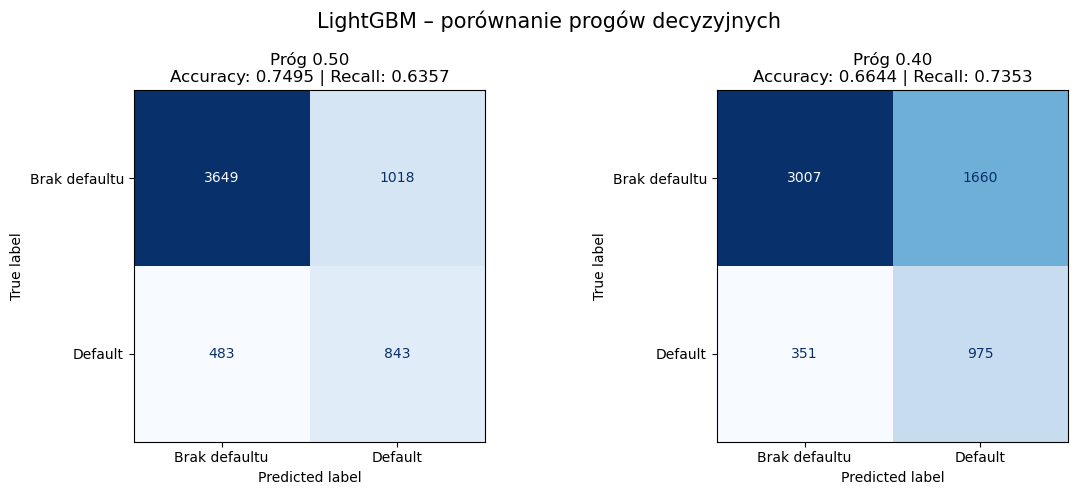

In [26]:
model = grid_lgbm.best_estimator_
y_proba = model.predict_proba(X_test)[:, 1]

progi = [0.50, 0.40]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, prog in enumerate(progi):
    y_pred = (y_proba >= prog).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Brak defaultu', 'Default'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f"Próg {prog:.2f}\nAccuracy: {acc:.4f} | Recall: {rec:.4f}", fontsize=12)

plt.suptitle("LightGBM – porównanie progów decyzyjnych", fontsize=15)
plt.tight_layout()
plt.show()

Jak widać poprawa wykrycia Default o 130 niesie za sobą konsekwencje w postaci 650 przypadków fałszywie pozytywnych przypisani. Jednak w przypadku ewentualnego braku spłaty proporcja 1/5 jest jak najbardziej pozytywna. ewentualne zyski z tych 650 klientów z dużą dozą prawdopodobieństwa nie przekroczą ewentualnych strat które 130 osób mogłyby wyrządzić  